# L2.1 — Linear Regression (end-to-end pipeline)

Hands-on notebook for the lesson [`2-1-linear-regression.mdx`](../../llm-quest-theory/level-2/2-1-linear-regression.mdx).

> **Learning objectives**
> - Walk through the 5-step ML pipeline on a real-looking regression problem.
> - Fit the same model two ways — closed-form normal equation and gradient descent — and confirm they agree.
> - Read R², residual plots, and a train/test split; cross-check with `sklearn`.

## Connection to the theory
Covers **§1–§5** of the source `.mdx`. This is the first notebook where we put Level 0 + Level 1 together into a proper pipeline.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Step 1 — Load the California housing dataset
A small real-world dataset that ships with scikit-learn: predict median house value from 8 numerical features.

In [2]:
data = fetch_california_housing()
X_full, y_full = data.data, data.target
print("feature names:", data.feature_names)
print("X_full shape :", X_full.shape)
print("y_full range :", y_full.min(), "to", y_full.max(), "(in units of $100k)")

feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_full shape : (20640, 8)
y_full range : 0.14999 to 5.00001 (in units of $100k)


## 2. Step 2 — Train/test split + feature scaling
We fit the `StandardScaler` on the train set only and reuse it for test — a mini anti-leakage discipline that the next lesson will formalise.

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=SEED)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
print("train shape:", X_tr_s.shape, "  test shape:", X_te_s.shape)
print("means of X_tr_s (should be ~0):", np.round(X_tr_s.mean(axis=0), 3))

train shape: (16512, 8)   test shape: (4128, 8)
means of X_tr_s (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0.]


## 3. Step 3 — Closed-form solution (normal equation)

$$\mathbf{w}^* = (X^\top X)^{-1} X^\top \mathbf{y}$$

We prepend a column of ones to `X_tr_s` to absorb the bias into `w`.

In [4]:
X_tr_aug = np.column_stack([X_tr_s, np.ones(len(X_tr_s))])
X_te_aug = np.column_stack([X_te_s, np.ones(len(X_te_s))])

# Prefer lstsq over explicit inverse: more numerically stable.
w_cf, *_ = np.linalg.lstsq(X_tr_aug, y_tr, rcond=None)
y_hat_tr_cf = X_tr_aug @ w_cf
y_hat_te_cf = X_te_aug @ w_cf

print("Closed-form coefficients (last entry = bias):")
print(np.round(w_cf, 3))

Closed-form coefficients (last entry = bias):
[ 8.540e-01  1.230e-01 -2.940e-01  3.390e-01 -2.000e-03 -4.100e-02
 -8.970e-01 -8.700e-01  2.072e+00]


## 4. Step 3b — Gradient descent on the same problem
Using the matrix form of MSE: `L = (1/N) * ||X w - y||^2`, `grad = (2/N) * X^T (X w - y)`.

In [5]:
def fit_gd(X, y, lr=0.05, n_steps=2000):
    w = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_steps):
        resid = X @ w - y
        grad  = 2 * X.T @ resid / len(y)
        w    -= lr * grad
        losses.append(float(np.mean(resid ** 2)))
    return w, np.array(losses)

w_gd, losses = fit_gd(X_tr_aug, y_tr)
y_hat_te_gd = X_te_aug @ w_gd

print("Closed-form vs GD max coefficient diff:", float(np.max(np.abs(w_cf - w_gd))))

Closed-form vs GD max coefficient diff: 2.288157140617475e-05


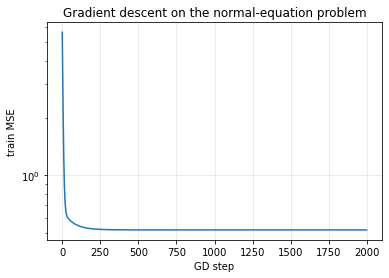

In [6]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("GD step"); ax.set_ylabel("train MSE")
ax.set_yscale("log"); ax.grid(alpha=0.3)
ax.set_title("Gradient descent on the normal-equation problem")
plt.show()

## 5. Step 4 — Cross-check with `sklearn.LinearRegression`
Sklearn uses its own (SVD-based) closed-form solver. The coefficients should match our `w_cf` almost exactly.

In [7]:
sk = LinearRegression().fit(X_tr_s, y_tr)
print("sklearn coef_    :", np.round(sk.coef_, 3))
print("closed-form coef :", np.round(w_cf[:-1], 3))
print("sklearn intercept:", round(float(sk.intercept_), 3),
      "  closed-form bias:", round(w_cf[-1], 3))

sklearn coef_    : [ 0.854  0.123 -0.294  0.339 -0.002 -0.041 -0.897 -0.87 ]
closed-form coef : [ 0.854  0.123 -0.294  0.339 -0.002 -0.041 -0.897 -0.87 ]
sklearn intercept: 2.072   closed-form bias: 2.072


## 6. Step 5 — Metrics: MSE, RMSE, R²
R² is a scale-free way to answer "is my model better than predicting the mean?"

In [8]:
def report(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<20} MSE={mse:.3f}  RMSE={rmse:.3f}  R^2={r2:.3f}")

report("train closed-form",  y_tr,  y_hat_tr_cf)
report("test  closed-form",  y_te,  y_hat_te_cf)
report("test  gradient desc", y_te, y_hat_te_gd)
# Baseline: always predict the train mean
baseline = np.full_like(y_te, y_tr.mean())
report("test  mean baseline", y_te, baseline)

train closed-form    MSE=0.518  RMSE=0.720  R^2=0.613
test  closed-form    MSE=0.556  RMSE=0.746  R^2=0.576
test  gradient desc  MSE=0.556  RMSE=0.746  R^2=0.576
test  mean baseline  MSE=1.311  RMSE=1.145  R^2=-0.000


The mean baseline has R² = 0 by definition. Anything above 0 is learning something; R² close to 1 is very good.

## 7. Residual diagnostics
If the residuals are randomly scattered around 0, linear regression is a reasonable fit. Any pattern (curve, funnel) tells you the model is missing structure or that the variance is not constant.

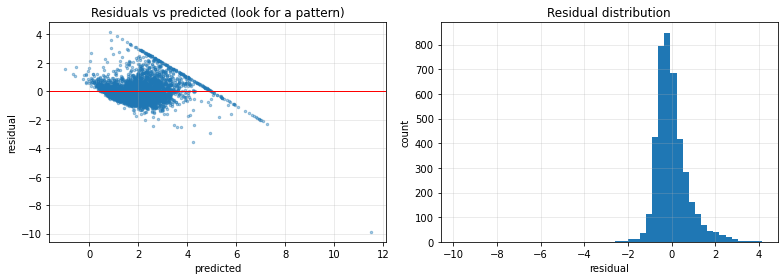

In [9]:
resid = y_te - y_hat_te_cf

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_hat_te_cf, resid, s=6, alpha=0.4)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs predicted (look for a pattern)"); axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=50)
axes[1].set_xlabel("residual"); axes[1].set_ylabel("count")
axes[1].set_title("Residual distribution"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Observation: residuals fan out at higher predicted prices and the distribution has a long right tail (capped at $500k in the original data). A plain linear model already captures the trend but leaves room for non-linear methods later.

## 8. Which features matter?
With standardised inputs, the magnitude of each coefficient is comparable across features.

In [10]:
names = data.feature_names
coefs = w_cf[:-1]
order = np.argsort(-np.abs(coefs))
for i in order:
    print(f"{names[i]:<12} coef = {coefs[i]:+.3f}")

Latitude     coef = -0.897
Longitude    coef = -0.870
MedInc       coef = +0.854
AveBedrms    coef = +0.339
AveRooms     coef = -0.294
HouseAge     coef = +0.123
AveOccup     coef = -0.041
Population   coef = -0.002


## 9. Quick checks

In [11]:
assert np.allclose(w_cf, w_gd, atol=1e-2), "GD must reach closed-form"
assert np.allclose(sk.coef_, w_cf[:-1], atol=1e-6)
assert r2_score(y_te, y_hat_te_cf) > 0.55, "linear model should explain > 55% of variance"
assert r2_score(y_te, baseline) < 1e-6,   "mean baseline must have R^2 ~ 0"
print("OK — all three solvers agree and the model clears the baseline.")

OK — all three solvers agree and the model clears the baseline.


## Reflection questions

1. The normal equation costs `O(d^3)` for matrix inversion. For an LLM embedding with `d = 4096`, would you still use it? What about GD?
2. Why prefer `np.linalg.lstsq` over the explicit `(X^T X)^-1 X^T y`?
3. The residual plot funnels out at higher predicted prices. What assumption of linear regression does that violate — and what technique would you reach for next?
4. If you standardise the target `y` as well, do the coefficients on the standardised inputs change? What stays invariant?

## References
- Source theory: [`2-1-linear-regression.mdx`](../../llm-quest-theory/level-2/2-1-linear-regression.mdx)
- Next: [`2-2-logistic-regression`](2-2-logistic-regression.ipynb)